# Temporal Difference (TD) learning - Q Learning algorithm

## Setup environment

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

## TD learning - Q-learning algorithm

- SARSA can estimate the action values of the given policy. It must combine with the policy improvement step to find the optimal policy.
- Q-learning directly estimates the optimal action values, so there is no need to alternate between policy evaluation and policy improvement.

- There exists two policies in TD learning task
  - the behavior policy is used to generate experience samples
  - the target policy is constantly updated toward an optimal policy
- On-policy vs off-policy
  - On-policy: when behavior policy is same as target policy; sarsa is an on-policy algorithm
  - Off-policy: when they are different; q-learning is an off-policy algorithm

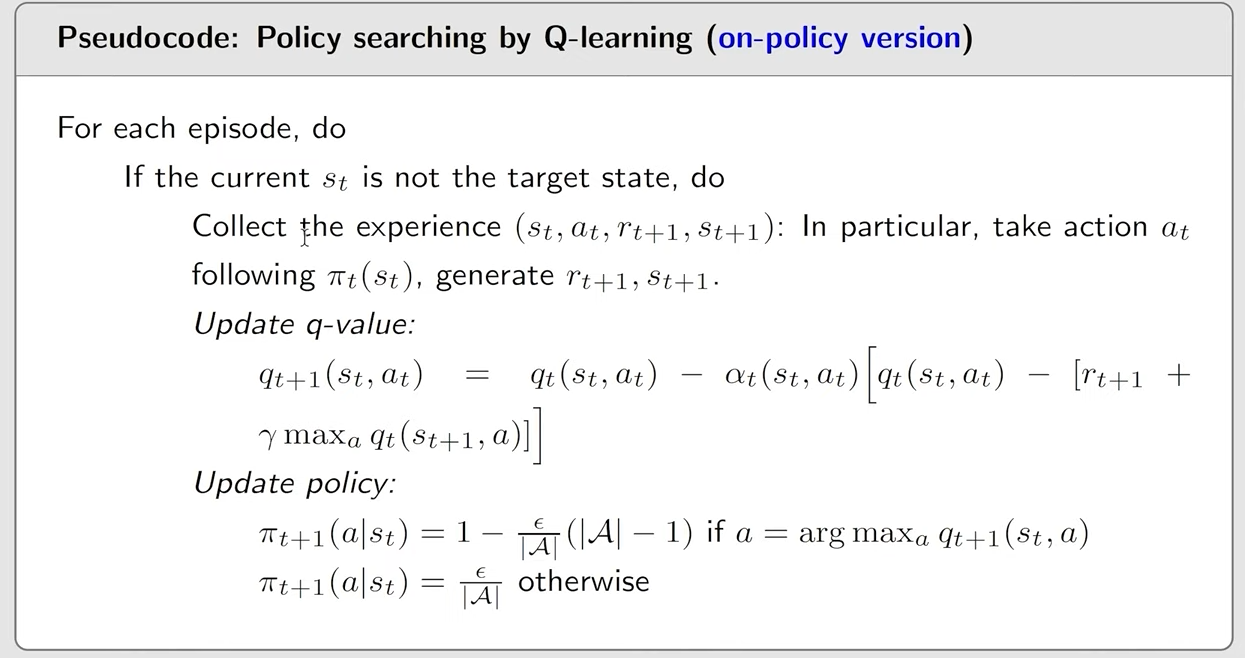

In [4]:
import random

In [5]:
# def randomly_state_action_pair(state_list, action_list):
#     # select element uniformly will ensure all the state, action will be selected eventually
#     s = random.choice(state_list)    
#     a = random.choice(action_list)
#     return (s, a)

In [6]:
def get_epsilon_greedy_policy(Q, state, actions, epsilon=0.2):
    if random.random() < epsilon:
        return random.choice(actions) # explore
    else:
        return np.argmax(Q[state.idx]) # exploit


def get_greedy_policy(env, Q, states):
    policy = np.zeros(env.n_states, dtype=np.int8)
    for s in states:
        policy[s.idx] = np.argmax(Q[s.idx])
    return policy.tolist()

In [7]:
def run_episode(env, Q, state, action, episode_idx, alpha=0.1, gamma=0.1, verbose=0):
    step = 0
    while True:
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"] # True if hole or goal ?


        # ---- update Q value ----
        Q[state.idx][action] = Q[state.idx][action] - alpha*(Q[state.idx][action] - (reward + gamma*np.max(Q[next_state.idx]))) 
        # -----------------------

        prev_state = state
        state = next_state
        action = get_epsilon_greedy_policy(Q, next_state, env.all_action_idx)
        
        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {state.coord}")
        elif verbose == 2:
            states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
            policy = get_greedy_policy(env, Q, states_list)
            env.render(policy, state, episode_idx, step, reward)
            
        if is_terminated:
            break
            
        step += 1

    states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]        
    greedy_policy = get_greedy_policy(env, Q, states_list)
    
    return Q, greedy_policy

In [8]:
def run_q_learning(env, n_episodes=500, alpha=0.2, gamma=0.4, verbose=0):
    policy_history = []
    Q_history = []

    # states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    # actions_list = list(env.action_to_idx.values())
    
    policy = np.zeros(env.n_states, dtype=np.int32)    
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)
    
    for episode_idx in range(n_episodes):
        # ------- always starts from the same initial state --------
        # s, a = randomly_state_action_pair(states_list,
        #                                   actions_list)
        initial_state = env.find('S')
        initial_action = 2 #randomly picked
        
        Q, greedy_policy = run_episode(env,
                                       Q, 
                                       initial_state, 
                                       initial_action, 
                                       episode_idx,
                                       alpha=0.2,
                                       gamma=0.4,
                                       verbose=verbose)

        policy_history.append(greedy_policy)
        Q_history.append(Q)
    return Q, policy_history, Q_history

In [9]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points = reward_points,
                                    slippery=True)

In [10]:
frozen_lake.n_rows

4

In [11]:
Q, policy_history, Q_history = run_q_learning(frozen_lake, n_episodes=1500, verbose=0)

In [12]:
policy = policy_history[-1]
np.array(policy)

array([2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 2, 0, 0, 0, 3, 0])

In [13]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [14]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 2, 2, 1],
       [2, 1, 0, 1],
       [2, 2, 2, 0],
       [0, 0, 3, 0]], dtype=int16)

# Render policy

In [15]:
import pandas as pd
from IPython.display import display

In [16]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,→,→,🚀 →,↓
1,→,↓,🕳️,↓
2,→,→,→,🏁
3,←,🕳️,↑,←


## Animate policy history

In [17]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [18]:
ani = animate_policy_value_video(frozen_lake, policy_history[-10:]) #plotting only last 10 history
HTML(ani.to_jshtml())

# Play with different grid setup

In [19]:
grid = generate_grid_randomly(4, 4, n_holes=4)
grid

[['G', 'F', 'S', 'H'],
 ['F', 'H', 'F', 'F'],
 ['F', 'F', 'F', 'F'],
 ['F', 'F', 'H', 'H']]

In [20]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [21]:
Q, policy_history, Q_history = run_q_learning(frozen_lake, n_episodes=5000, verbose=0)

In [22]:
policy = policy_history[-1]

In [23]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,🏁,←,🚀 ←,🕳️
1,↑,🕳️,↑,←
2,←,←,↑,←
3,←,←,🕳️,🕳️
